In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------------------------- ------ 2.4/2.8 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 11.6 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   --- ------------------------------------ 3.4/41.9 MB 16.8 MB/s eta 0:00:03
   ------ --------------------------------- 7.1/41.9 MB 16.8 MB/s eta 0:00:03
   --------- ------------------------------ 10.2/41.9 MB 16.4 MB/s eta 0:00:02
   ------------ --------------------------- 13.4/41.9 MB 16.4 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/41.9 MB 16.0 MB/s eta 0:00:02
   ------------------- -------------------- 20.2/41.9 MB 15.9 MB/s eta 0:00:02
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras 3.8.0 requires ml-dtypes, which is not installed.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.


In [3]:
import numpy
print(numpy.__version__)

2.2.6


In [3]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras 3.8.0 requires ml-dtypes, which is not installed.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.



  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
  Using cached numba-0.66.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.48.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.66.0-cp312-cp312-win_amd64.whl (2.8 MB)
Using cached llvmlite-0.48.0-cp312-cp312-win_amd64.whl (41.9 MB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)

   -------- ------------------------------- 1/5 [numpy]
   -------- 

In [4]:
import numpy
import pandas
import shap

print(numpy.__version__)
print(pandas.__version__)
print(shap.__version__)

1.26.4
2.2.2
0.52.0


In [6]:
import pandas as pd
import numpy as np
import shap
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [8]:
transaction = pd.read_csv("datasets/train_transaction.csv")

identity = pd.read_csv("datasets/train_identity.csv")

df = transaction.merge(
    identity,
    on="TransactionID",
    how="left"
)

In [9]:
missing = (df.isnull().sum()/len(df))*100

drop_cols = missing[missing>80].index

df.drop(columns=drop_cols,inplace=True)

In [10]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [11]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [12]:
X = df.drop(columns=["TransactionID","isFraud"])

y = df["isFraud"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = joblib.load("xgboost_model.pkl")

print("Model Loaded")

Model Loaded


In [15]:
explainer = shap.TreeExplainer(model)

In [16]:
sample = X_test.iloc[[0]]

shap_values = explainer(sample)

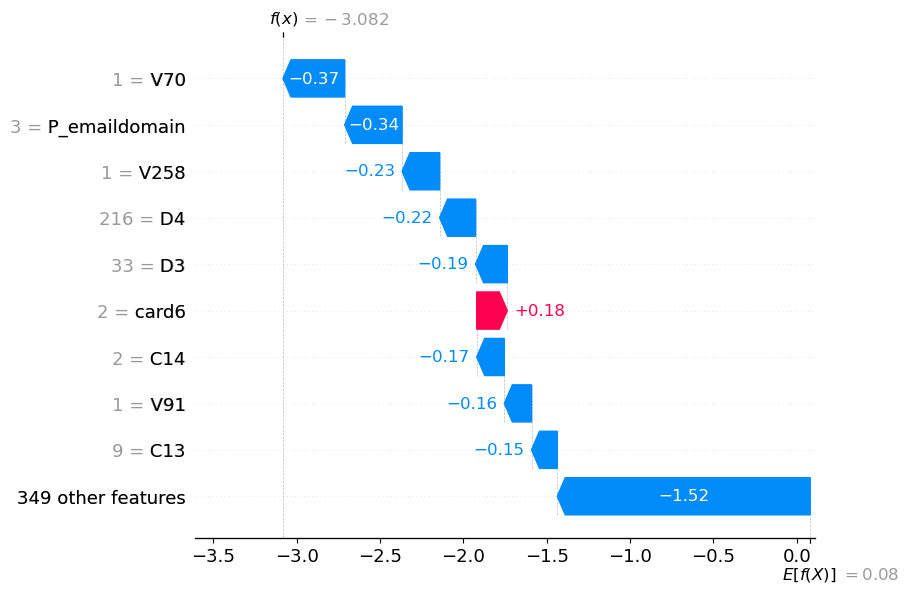

In [17]:
shap.plots.waterfall(shap_values[0])